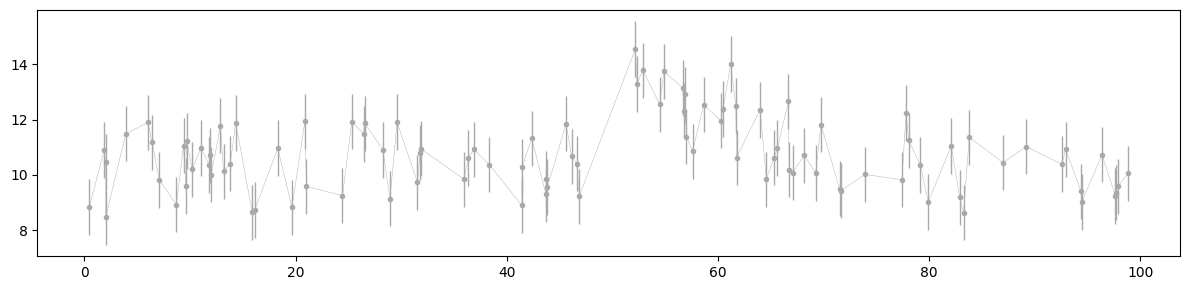

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

infile = '../solutions/transient.npy'
data = np.load(infile)
time, flux, yerr = data[:,0], data[:,1], data[:,2]
fig, axs = plt.subplots(tight_layout=True, figsize=(12,3))
_ = axs.errorbar(time, flux, yerr=yerr, marker='.', lw=0.3, elinewidth=1, c='darkgray')

In [121]:
from numba import njit, float64
import scipy
from scipy.stats import uniform

uGrid = np.linspace(0, 1, 15000)
ppf_bkg      = np.array( scipy.stats.uniform(0, 50).ppf(uGrid) )
ppf_bAmpl    = np.array( scipy.stats.uniform(0, 15).ppf(uGrid) ) ### Squeezing the domain from 50 to 15.
ppf_t0       = np.array( scipy.stats.uniform(0,100).ppf(uGrid) ) 
ppf_logAlpha = np.array( scipy.stats.uniform(-5, 5).ppf(uGrid) ) ### Squeezing the domain from -5,5 to -3,+3

ppf_gAmpl    = np.array( scipy.stats.uniform(1, 10).ppf(uGrid) )
ppf_sigmaW   = np.array( scipy.stats.uniform(2, 20).ppf(uGrid) )
# ppf_logSigmaW = np.array( scipy.stats.uniform(0, 1).ppf(uGrid))

@njit(float64[:](float64[:]))
def uPrior_1(params):
    x0 = ppf_bkg     [ ( np.abs(uGrid - params[0]) ).argmin() ]
    x1 = ppf_bAmpl   [ ( np.abs(uGrid - params[1]) ).argmin() ]
    x2 = ppf_t0      [ ( np.abs(uGrid - params[2]) ).argmin() ]
    x3 = ppf_logAlpha[ ( np.abs(uGrid - params[3]) ).argmin() ]
    return np.array([x0, x1, x2,x3]) 

@njit(float64(float64, float64[:]))
def Model_1(t, params):
    bkg, bAmpl, t0, logalpha = params
    if t < t0: return bkg
    alpha = 10**logalpha
    return bkg + bAmpl*np.exp(-alpha*(t-t0))

@njit(float64(float64[:]))
def logLikelihood_1(params):
    logL = 0
    for t, f, rms in zip(time, flux, yerr):
        logL = logL - ( f - Model_1(t, params) )**2 / 2*np.pi/rms**2 - 0.5*np.log10(2*np.pi*rms**2)
    if np.isnan(logL) == True: return -np.inf
    return logL

@njit(float64[:](float64[:]))
def uPrior_2(params):
    x0 = ppf_bkg   [ ( np.abs(uGrid - params[0]) ).argmin() ]
    x1 = ppf_gAmpl [ ( np.abs(uGrid - params[1]) ).argmin() ]
    x2 = ppf_t0    [ ( np.abs(uGrid - params[2]) ).argmin() ]
    x3 = ppf_sigmaW[ ( np.abs(uGrid - params[3]) ).argmin() ]
    ### x3 = ppf_logSigmaW[ ( np.abs(uGrid - params[3]) ).argmin() ]
    return np.array([x0, x1, x2,x3]) 

@njit(float64(float64, float64[:]))
def Model_2(t, params):
    bkg, gAmpl, t0, sigmaW = params
    return bkg + gAmpl*np.exp(-(t-t0)**2 / (2 * sigmaW**2) )
    # return bkg + gAmpl*np.exp(-(t-t0)**2 / (2 * (10**sigmaW)**2) )

@njit(float64(float64[:]))
def logLikelihood_2(params):
    logL = 0
    for t, f, rms in zip(time, flux, yerr):
        logL = logL - ( f - Model_2(t, params) )**2 / 2*np.pi/rms**2 - 0.5*np.log10(2*np.pi*rms**2)
    if np.isnan(logL) == True: return -np.inf
    return logL
# print('Ready!')

In [100]:
import dynesty
import warnings
warnings.filterwarnings("ignore") ### Ruthless, but very effective!
ndim = 4
# sampler_1 = dynesty.NestedSampler(logLikelihood_1, uPrior_1, ndim, nlive=300)
sampler_1 = dynesty.DynamicNestedSampler(logLikelihood_1, uPrior_1, ndim)
sampler_1.run_nested(print_progress=True)
sresults_1 = sampler_1.results

### uGrid = 100000 points, NestedSampler
# 300 LP : 2min22s
# 500 LP : 3min50s

### uGrid 1000000 points, DynamicNestedSampler
# 03min33s, best fit!

18239it [01:01, 298.85it/s, batch: 7 | bound: 12 | nc: 1 | ncall: 156463 | eff(%): 11.497 | loglstar: -198.289 < -193.071 < -193.436 | logz: -208.206 +/-  0.108 | stop:  0.945]           


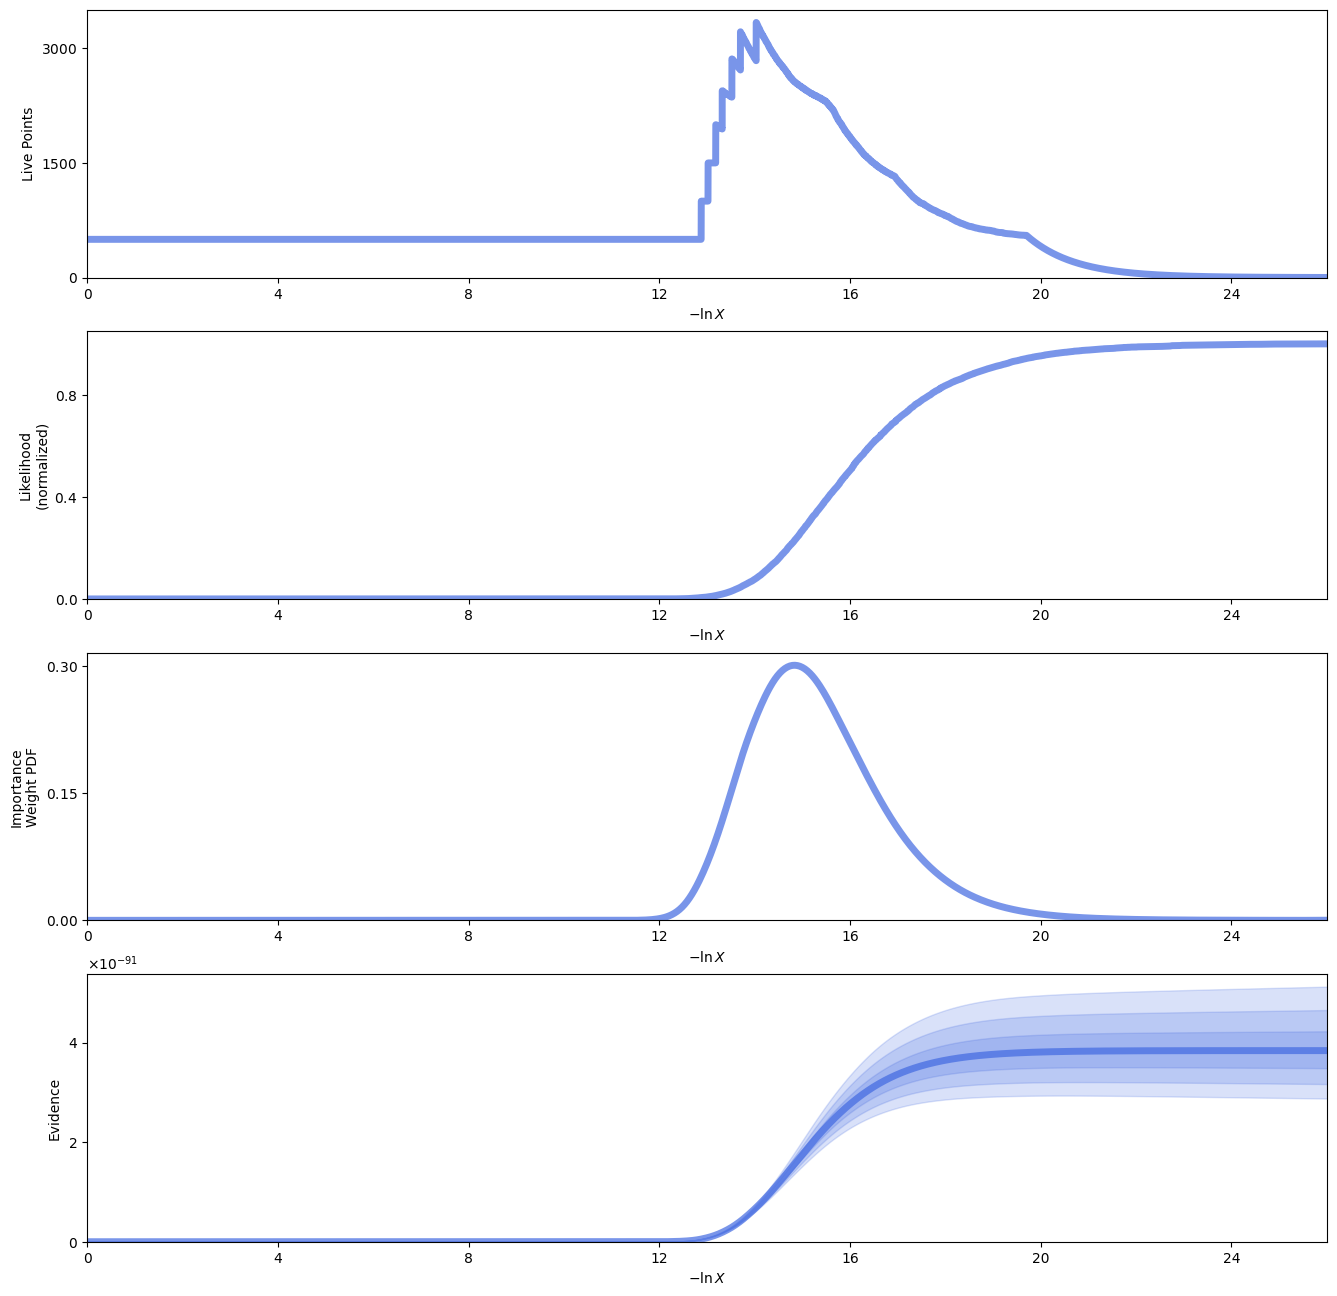

In [101]:
# Plot a summary of the run.
from dynesty import plotting as dyplot
rfig, raxes = dyplot.runplot(sresults_1, color='royalblue')

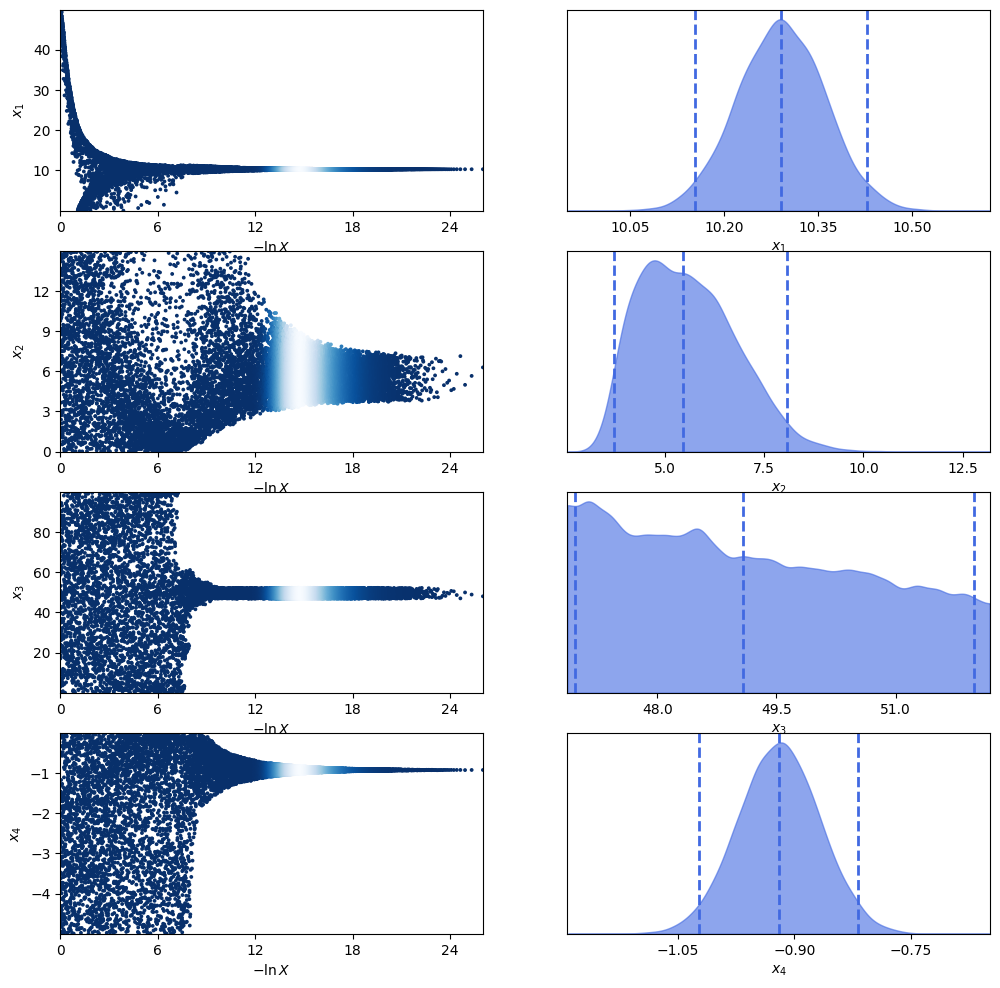

In [102]:
tfig, taxes = dyplot.traceplot(sresults_1, trace_cmap='Blues_r', post_color='royalblue')

from dynesty import utils as dyfunc
import corner
samples = sresults_1.samples  # samples
weights = np.exp(sresults_1.logwt - sresults_1.logz[-1])  # normalized weights

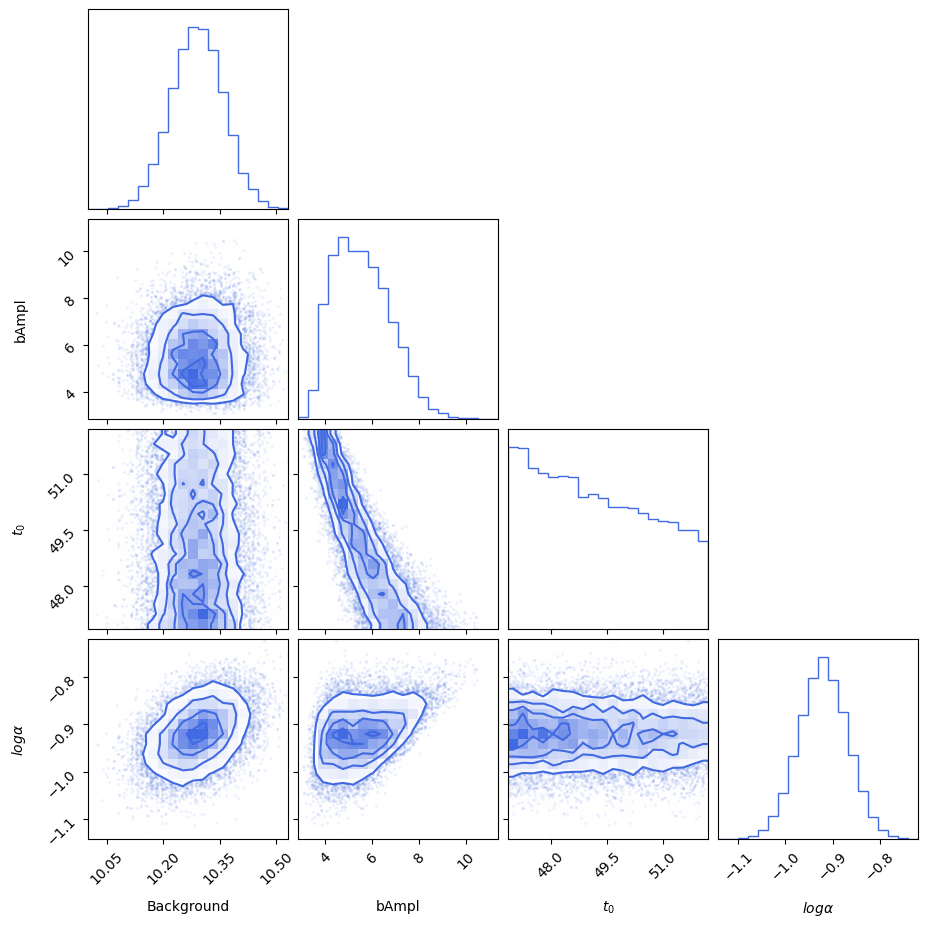

In [103]:
labels = ["Background","bAmpl","$t_{0}$",r"$log\alpha$"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal, labels=labels, color='royalblue');

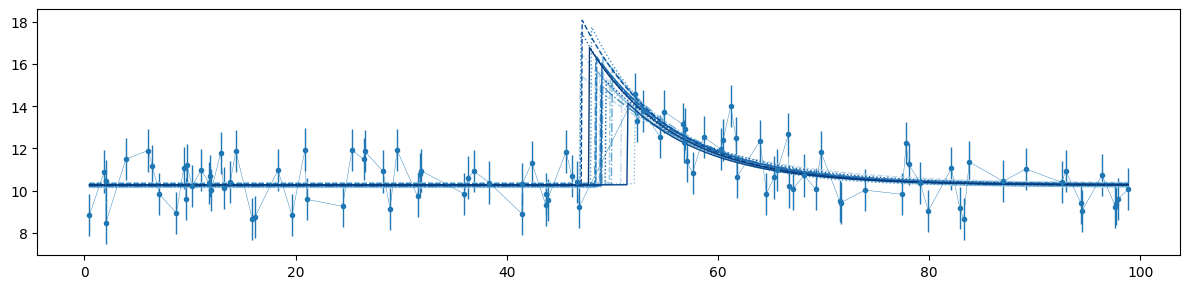

In [104]:
params = np.array( samples_equal[np.random.choice(np.shape(samples_equal)[0])], dtype=np.float64)
fig, axs = plt.subplots(tight_layout=True, figsize=(12,3))
axs.errorbar(time, flux, yerr=yerr, marker='.', lw=0.3, elinewidth=1)
idxs = np.random.choice(np.shape(samples_equal)[0], 20)
import seaborn as sns
Blues = sns.color_palette('Blues', n_colors=len(idxs)+3)[3:]
xTime = np.linspace(min(time), max(time), 1000)
for i, params in enumerate(np.array(samples_equal[idxs][:], dtype=np.float64)):
    axs.plot(xTime, [Model_1(t, params) for t in xTime], c=Blues[i], lw=1, ls=np.random.choice(['--', '-.', '-', ':']))

In [122]:
sampler_2 = dynesty.DynamicNestedSampler(logLikelihood_2, uPrior_2, ndim)#, nlive=500)
sampler_2.run_nested(print_progress=True)
sresults_2 = sampler_2.results

19233it [00:24, 795.65it/s, batch: 7 | bound: 6 | nc: 1 | ncall: 63316 | eff(%): 30.227 | loglstar: -210.406 < -204.564 < -205.429 | logz: -220.445 +/-  0.108 | stop:  0.854]             


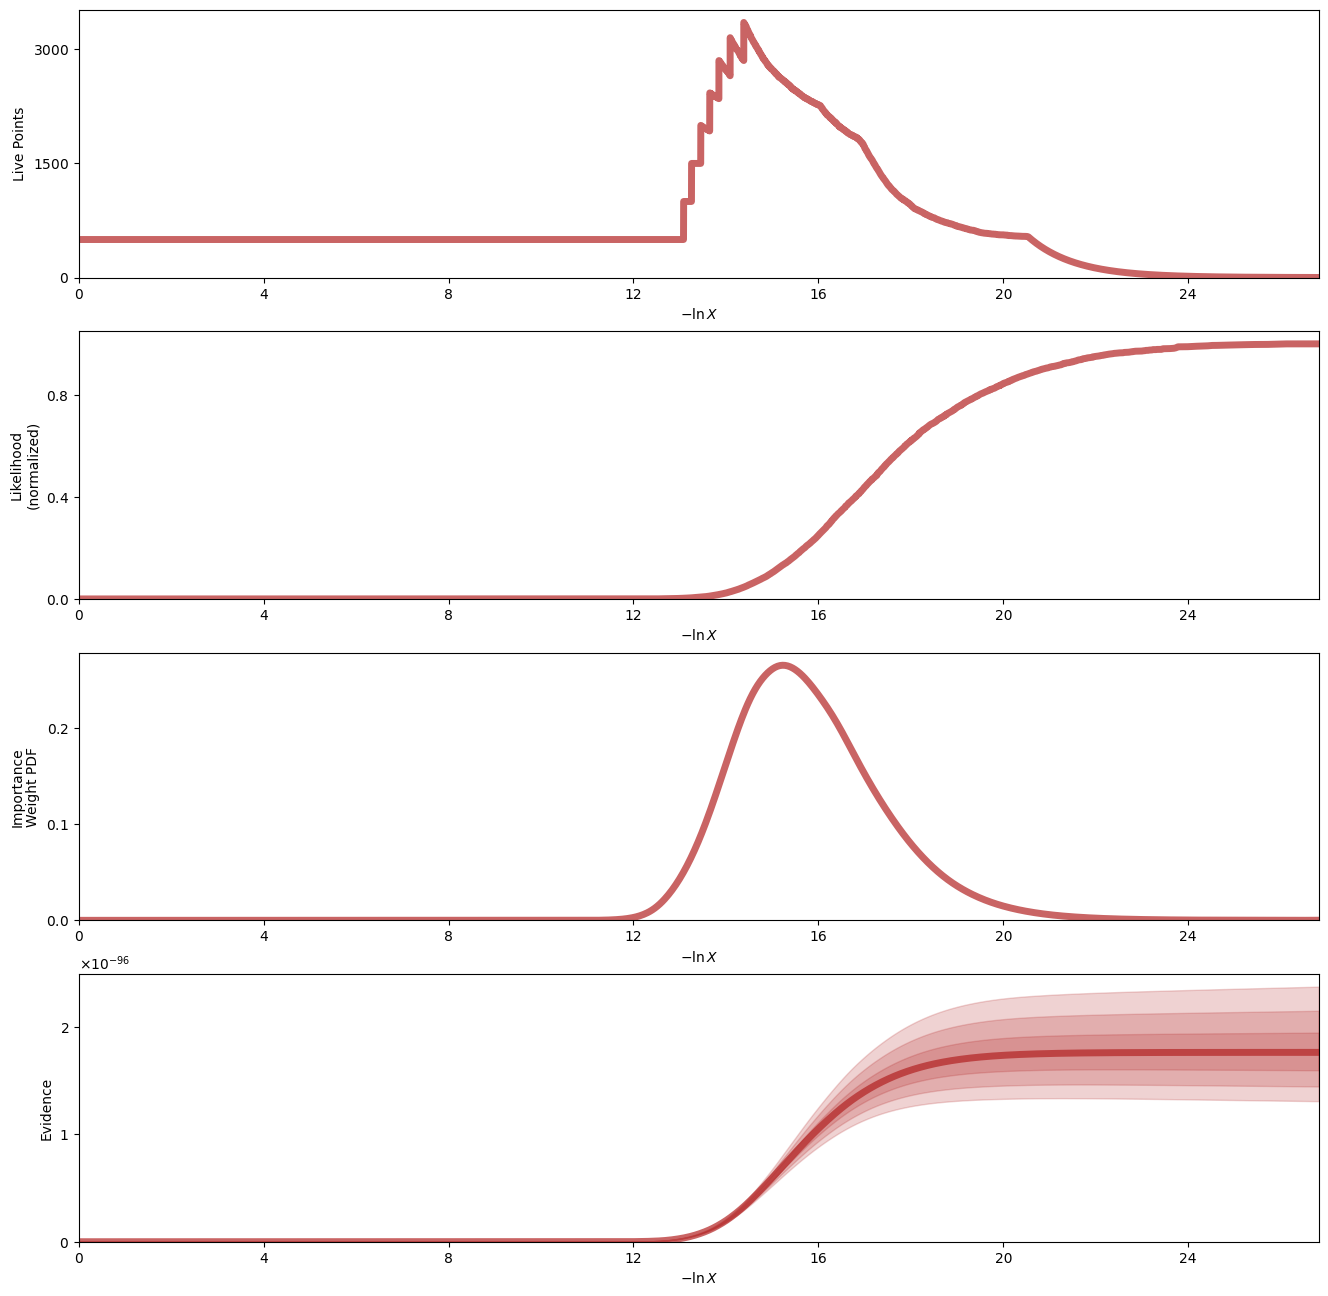

In [123]:
from dynesty import plotting as dyplot
rfig, raxes = dyplot.runplot(sresults_2, color='firebrick')

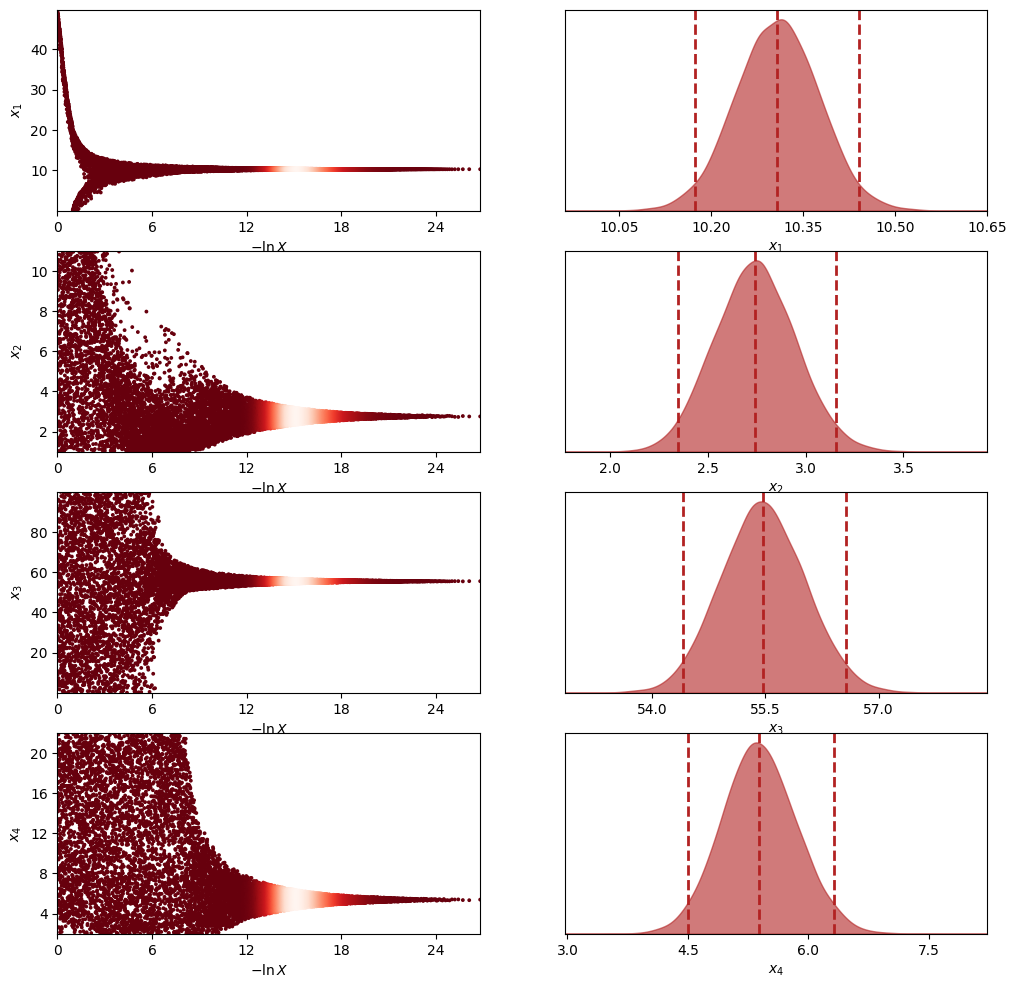

In [124]:
tfig, taxes = dyplot.traceplot(sresults_2, trace_cmap='Reds_r', post_color='firebrick')

from dynesty import utils as dyfunc
import corner
samples = sresults_2.samples  # samples
weights = np.exp(sresults_2.logwt - sresults_2.logz[-1])  # normalized weights

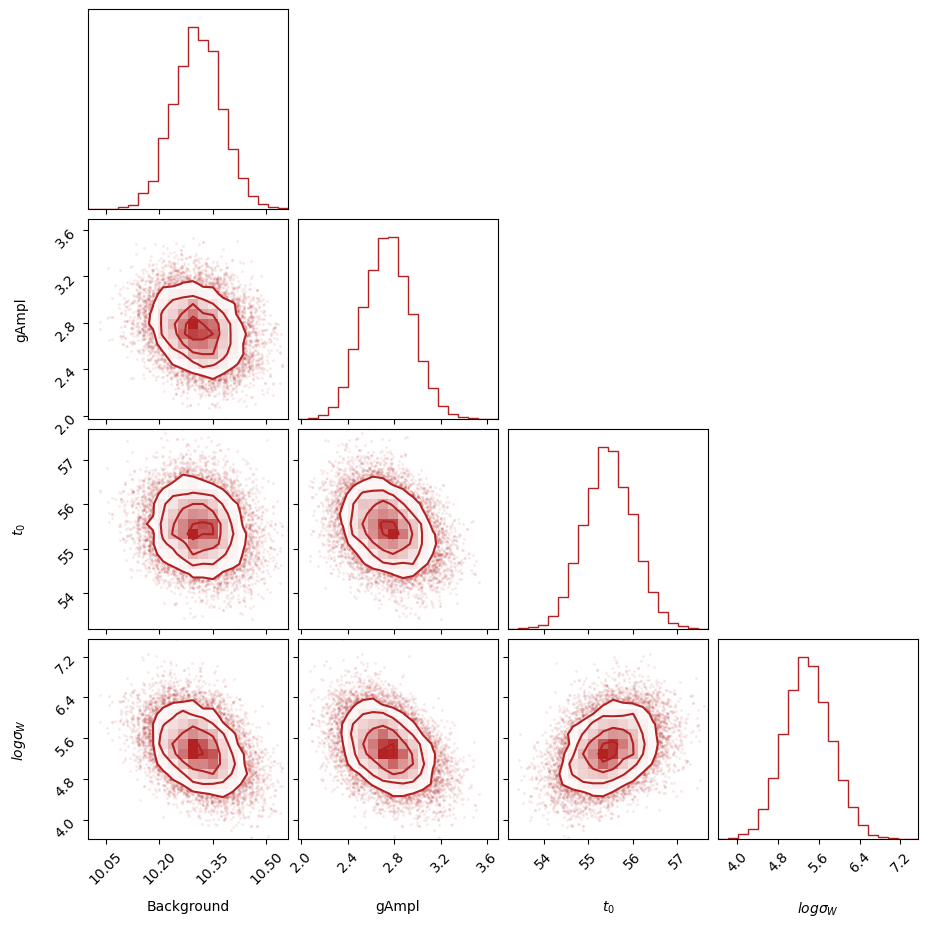

In [125]:
labels = ["Background","gAmpl","$t_{0}$",r"$log\sigma_{W}$"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal, labels=labels, color='firebrick');

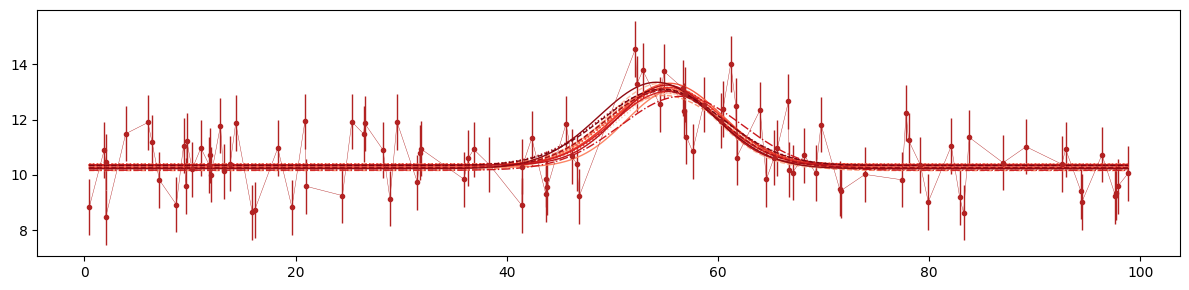

In [126]:
params = np.array( samples_equal[np.random.choice(np.shape(samples_equal)[0])], dtype=np.float64)
fig, axs = plt.subplots(tight_layout=True, figsize=(12,3))
axs.errorbar(time, flux, yerr=yerr, marker='.', lw=0.3, elinewidth=1, c='firebrick')
idxs = np.random.choice(np.shape(samples_equal)[0], 20)

xTime = np.linspace(min(time), max(time), 1000)
Reds  = sns.color_palette('Reds', n_colors=len(idxs)+3)[3:]
for i, params in enumerate(np.array(samples_equal[idxs][:], dtype=np.float64)):
    axs.plot(xTime, [Model_2(t, params) for t in xTime], c=Reds[i], lw=1, ls=np.random.choice(['--', '-.', '-', ':']))

In [127]:
print('Burst Model')
sresults_1.summary()
print()

print('Gaussian Profile')
sresults_2.summary()
print()

print('Odds Ratio', np.exp(sresults_1.logz[-1])/np.exp(sresults_2.logz[-1]) )

Burst Model
Summary
niter: 18239
ncall: 146987
eff(%): 11.497
logz: -208.190 +/-  0.096

Gaussian Profile
Summary
niter: 19233
ncall: 62205
eff(%): 30.227
logz: -220.482 +/-  0.099

Odds Ratio 217851.01657867894


#### I'd say the odds are not in the gaussian model's favor.

In [112]:
### NOTE SULLA PARTE CON dynesty

# Code up the two models.
# definisci logL gaussiana come prima (ASSUMPTION)
# NON traccia la normalizzazione della likelihood perché le evidence sono SBAGLIATE ma il RATIO rimane uguale.
# usa dynesty: devi trasformare la prior!
# osserva come vanno i traceplot e i livepoints per capire se hai fatto un buon lavoro o meno
# fai dei cornerplot e confrontali con quelli della volta precedente
# summary statistics in the end: .summary()
# logZ è il log dell'evidence, ma ha senso quando fai il RATIO tra le due evidence.
# la sigmaW ha un ""bias"" perché tronchi la distribuzione in un range, ma probabilmente arriva un po' più a dx. sull'asse

# summary results wrong, ratio sarebbe ok
# 130: expo tail better than the other model -> VERY strong evidence.

# CHECK is number is solid: cambi i live points, quanto cambia? ecc. Assegna un errore ai tuoi risultati. 
# Esempio: il codice runna di nuovo: esce 90 al posto di 130, quindi hai un 20% or something che NON e' negligible! 
# -> more live points, rendi il codice più stabile. (esempio di approach)